In [1]:
import keystroke_cvae_module as kc

In [2]:
kc.set_seed(42)

In [3]:
df, X, C, scaler, encoder, feature_cols = kc.load_data("cmu_keystroke.csv")

Data shape: (20400, 33)
Feature shape: (20400, 31)
Condition shape: (20400, 59)


In [4]:
df_train, df_val, df_test, X_train, X_val, X_test, C_train, C_val, C_test = kc.split_data_by_user_session(df, X, C)

Train: (14280, 31) (14280, 59)
Val  : (3264, 31) (3264, 59)
Test : (2856, 31) (2856, 59)


In [5]:
train_loader, val_loader = kc.create_loaders(X_train, X_val, C_train, C_val, batch_size=64)

In [6]:
model = kc.build_model(X_train.shape[1], C_train.shape[1], latent_dim=48, dropout=0.15)

In [7]:
model, train_losses, val_losses = kc.train(model, train_loader, val_loader, epochs=30, lr=0.0005, beta=0.0005)

Epoch 1/30 | Train 0.6833 | Val 0.7444
Epoch 2/30 | Train 0.5281 | Val 0.7057
Epoch 3/30 | Train 0.4444 | Val 0.5743
Epoch 4/30 | Train 0.3266 | Val 0.4942
Epoch 5/30 | Train 0.2494 | Val 0.4241
Epoch 6/30 | Train 0.1940 | Val 0.3916
Epoch 7/30 | Train 0.1638 | Val 0.3805
Epoch 8/30 | Train 0.1496 | Val 0.3307
Epoch 9/30 | Train 0.1389 | Val 0.3112
Epoch 10/30 | Train 0.1287 | Val 0.2846
Epoch 11/30 | Train 0.1195 | Val 0.2416
Epoch 12/30 | Train 0.1106 | Val 0.1746
Epoch 13/30 | Train 0.1042 | Val 0.1343
Epoch 14/30 | Train 0.1007 | Val 0.0903
Epoch 15/30 | Train 0.0971 | Val 0.0958
Epoch 16/30 | Train 0.0892 | Val 0.0800
Epoch 17/30 | Train 0.0919 | Val 0.0719
Epoch 18/30 | Train 0.0849 | Val 0.0666
Epoch 19/30 | Train 0.0791 | Val 0.0634
Epoch 20/30 | Train 0.0748 | Val 0.0561
Epoch 21/30 | Train 0.0738 | Val 0.0515
Epoch 22/30 | Train 0.0708 | Val 0.0665
Epoch 23/30 | Train 0.0702 | Val 0.0605
Epoch 24/30 | Train 0.0659 | Val 0.0537
Epoch 25/30 | Train 0.0665 | Val 0.0501
Epoch 26/

In [8]:
model, train_losses, val_losses = kc.train(model, train_loader, val_loader, epochs=150, lr=0.0005, beta=0.0005)

Epoch 1/150 | Train 0.0564 | Val 0.0518
Epoch 2/150 | Train 0.0552 | Val 0.0552
Epoch 3/150 | Train 0.0585 | Val 0.0704
Epoch 4/150 | Train 0.0578 | Val 0.0457
Epoch 5/150 | Train 0.0592 | Val 0.0391
Epoch 6/150 | Train 0.0524 | Val 0.0430
Epoch 7/150 | Train 0.0481 | Val 0.0451
Epoch 8/150 | Train 0.0481 | Val 0.0400
Epoch 9/150 | Train 0.0521 | Val 0.0344
Epoch 10/150 | Train 0.0466 | Val 0.0382
Epoch 11/150 | Train 0.0489 | Val 0.0357
Epoch 12/150 | Train 0.0472 | Val 0.0364
Epoch 13/150 | Train 0.0464 | Val 0.0410
Epoch 14/150 | Train 0.0452 | Val 0.0321
Epoch 15/150 | Train 0.0457 | Val 0.0287
Epoch 16/150 | Train 0.0446 | Val 0.0490
Epoch 17/150 | Train 0.0566 | Val 0.0563
Epoch 18/150 | Train 0.0538 | Val 0.0304
Epoch 19/150 | Train 0.0469 | Val 0.0311
Epoch 20/150 | Train 0.0429 | Val 0.0364
Epoch 21/150 | Train 0.0501 | Val 0.0321
Epoch 22/150 | Train 0.0446 | Val 0.0340
Epoch 23/150 | Train 0.0450 | Val 0.0310
Epoch 24/150 | Train 0.0433 | Val 0.0323
Epoch 25/150 | Train 0.04

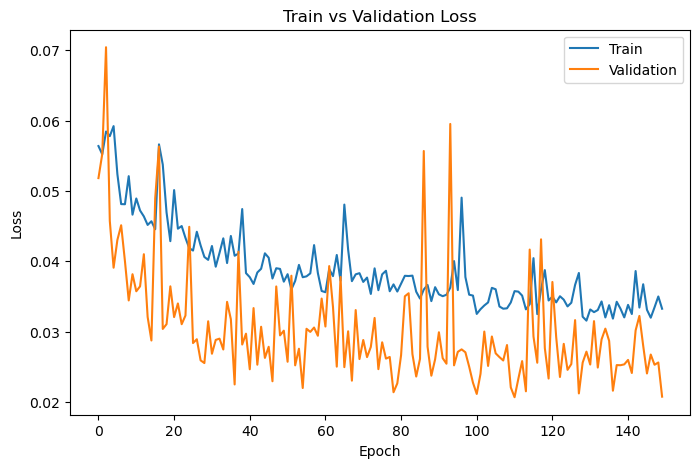

In [9]:
kc.plot_loss(train_losses, val_losses)

In [10]:
synthetic_df = kc.generate_same_shape(model, df, scaler, encoder, feature_cols)

Real shape      : (20400, 33)
Synthetic shape : (20400, 33)


In [11]:
kc.save_dataset(synthetic_df, "synthetic_cmu.csv")

Saved dataset to: /Users/shikharraj/Desktop/BB final project/VAE Synthetic generator/synthetic_cmu.csv


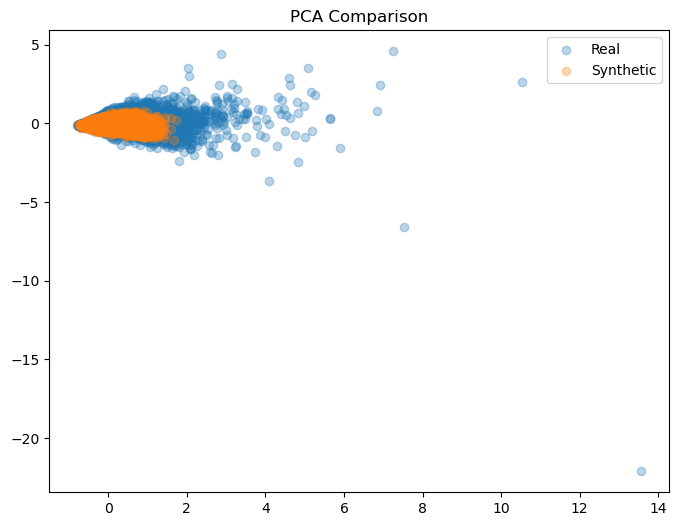

In [12]:
kc.plot_pca(df, synthetic_df, feature_cols)

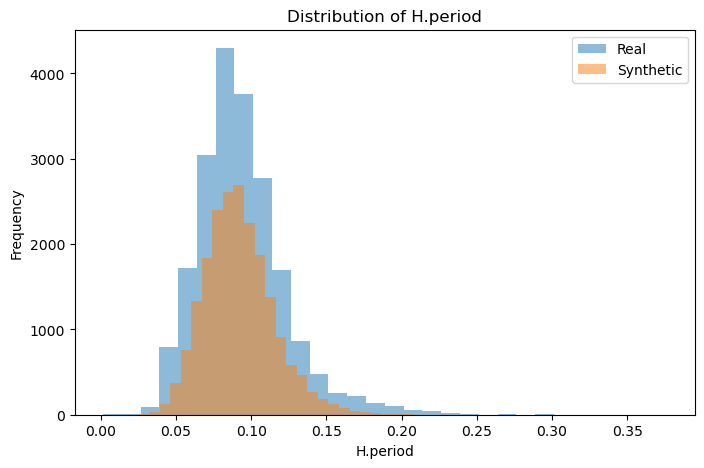

In [13]:
kc.plot_feature_hist(df, synthetic_df, feature_cols[0])

In [14]:
kc.compare_stats(df, synthetic_df, feature_cols, num_features=5)

REAL MEANS
H.period       0.093379
DD.period.t    0.264148
UD.period.t    0.170769
H.t            0.085727
DD.t.i         0.169085
dtype: float64

SYNTHETIC MEANS
H.period       0.091908
DD.period.t    0.262145
UD.period.t    0.168764
H.t            0.088279
DD.t.i         0.171660
dtype: float32

REAL STDS
H.period       0.029626
DD.period.t    0.220534
UD.period.t    0.226836
H.t            0.027424
DD.t.i         0.123546
dtype: float64

SYNTHETIC STDS
H.period       0.023020
DD.period.t    0.139833
UD.period.t    0.143904
H.t            0.022796
DD.t.i         0.072049
dtype: float32


In [15]:
kc.svm_utility_test(df, synthetic_df, feature_cols)

SVM accuracy (train real -> test real): 0.7897
SVM accuracy (train synthetic -> test real): 0.6659


(0.7897058823529411, 0.6659313725490196)